# ML for drug resistance in TB

In [38]:
# enables the %%R magic, not necessary if you've already done this
%load_ext rpy2.ipython

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_curve, auc
from sklearn.inspection import permutation_importance
from sklearn.feature_selection import RFE
from sklearn.feature_selection import RFECV
from sklearn.metrics import roc_auc_score, accuracy_score
import matplotlib.pyplot as plt


# Set seed for reproducibility
seed = 97
np.random.seed(seed)

# Load the dataset
drtb_path = "/Users/mraniereneves/Library/CloudStorage/OneDrive-YaleUniversity/Yale/TB/Republic of Moldova data/DATA_tb_moldova_NN.csv"
drtb = pd.read_csv(drtb_path)

# Split target and covariates
y = drtb['FLQ_R']
X = drtb.drop('FLQ_R', axis=1)

# Standardize specific features: 'Age'
features_to_standardize = ['Age']
scaler = StandardScaler()
X[features_to_standardize] = scaler.fit_transform(X[features_to_standardize])

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


Index(['Family_size', 'Age', 'prevalence_2', 'Family_size18', 'Urban_1',
       'Living_condition_1', 'TB_type_1', 'TB_type_2', 'Education_2',
       'Urban_0', 'Living_condition_0', 'Occupation_5', 'prevalence_0',
       'Money_assistance_0', 'prevalence_1', 'Education_1', 'Incarceration_0',
       'Microscopy_0'],
      dtype='object')


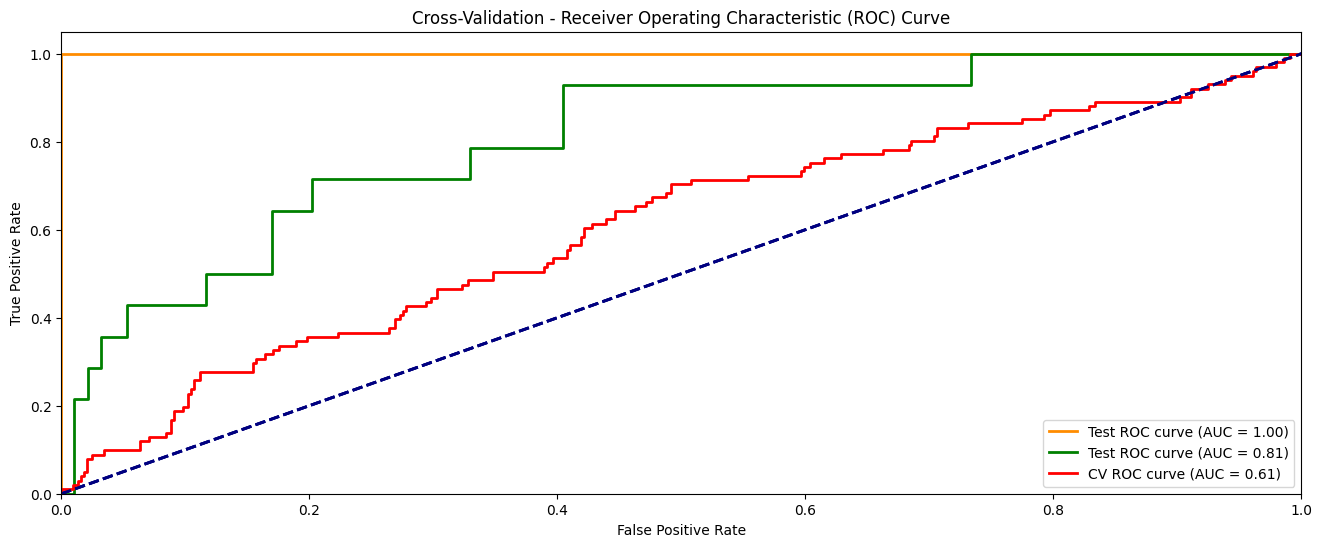


Overall AUROC across 5 folds with feature selection: 0.61
Overall AUROC on the test set with feature selection: 0.81
1.0
0.16002268023329144
Index(['Family_size', 'Age', 'prevalence_2', 'Family_size18', 'Urban_1',
       'Living_condition_1', 'TB_type_1', 'TB_type_2', 'Education_2',
       'Urban_0', 'Living_condition_0', 'Occupation_5', 'prevalence_0',
       'Money_assistance_0', 'prevalence_1', 'Education_1', 'Incarceration_0',
       'Microscopy_0'],
      dtype='object')
0.8399773197667085
Optimism-Corrected Performance: 0.8399773197667085
95.0% Bootstrap Confidence Interval: [0.7944385867971764, 0.8790102956764924]


In [43]:
# Define a neural network model with lbfgs solver, tanh activation, and one hidden layer
model = MLPClassifier(
    hidden_layer_sizes=(X.shape[1] + 2,),
    activation='tanh',
    solver='lbfgs',
    random_state=seed,
    max_iter=10000
)

# Fit the model on the entire dataset
model.fit(X, y)

# Compute permutation importance
perm_importance = permutation_importance(model, X, y, n_repeats=10, random_state=seed)
sorted_feature_indices = np.argsort(perm_importance.importances_mean)[::-1]
num_selected_features = 18
selected_features = X.columns[sorted_feature_indices[:num_selected_features]]

print(selected_features)

# Evaluate the model on full dataset
y_pred_probs_fulldata = model.predict_proba(X)[:, 1]

# Compute ROC curve and ROC area for the test set
fpr_fulldata, tpr_fulldata, _ = roc_curve(y, y_pred_probs_fulldata)
roc_auc_fulldata = auc(fpr_fulldata, tpr_fulldata)

# Perform 5-fold cross-validation and get true labels and predicted probabilities
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
y_true_cv = []
y_pred_probs_cv = []

for train, test in cv.split(X, y):
    # Train the model with selected features
    model.fit(X.iloc[train][selected_features], y.iloc[train])

    # Predict probabilities on the test set
    y_true_fold = y.iloc[test]
    y_pred_probs_fold = model.predict_proba(X.iloc[test][selected_features])[:, 1]

    y_true_cv.extend(y_true_fold)
    y_pred_probs_cv.extend(y_pred_probs_fold)

# Compute ROC curve and ROC area for cross-validation
fpr_cv, tpr_cv, _ = roc_curve(y_true_cv, y_pred_probs_cv)
roc_auc_cv = auc(fpr_cv, tpr_cv)

# Split the dataset into training and testing sets (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X[selected_features], y, test_size=0.2, random_state=seed)

# Train the model on the training set
model.fit(X_train, y_train)

# Evaluate the model on the test set
y_pred_probs_test = model.predict_proba(X_test)[:, 1]

# Compute ROC curve and ROC area for the test set
fpr_test, tpr_test, _ = roc_curve(y_test, y_pred_probs_test)
roc_auc_test = auc(fpr_test, tpr_test)

# Plot ROC curves side by side
plt.figure(figsize=(16, 6))

# ROC curve for the test set
#plt.subplot(1, 2, 1)
plt.plot(fpr_fulldata, tpr_fulldata, color='darkorange', lw=2, label=f'Test ROC curve (AUC = {roc_auc_fulldata:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Full Data - Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

# ROC curve for the test set
#plt.subplot(1, 2, 1)
plt.plot(fpr_test, tpr_test, color='green', lw=2, label=f'Test ROC curve (AUC = {roc_auc_test:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Test Set - Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

# ROC curve for cross-validation
#plt.subplot(1, 2, 2)
plt.plot(fpr_cv, tpr_cv, color='red', lw=2, label=f'CV ROC curve (AUC = {roc_auc_cv:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Cross-Validation - Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")

plt.show()

# Report overall AUROC
print(f"\nOverall AUROC across 5 folds with feature selection: {roc_auc_cv:.2f}")
print(f"Overall AUROC on the test set with feature selection: {roc_auc_test:.2f}")


#######################################
# Calculate the optmism corrected AUC #
#######################################

# Step 2: Bootstrap resampling
num_bootstrap_samples = 200
bootstrap_performances = []

for i in range(num_bootstrap_samples):
    # Create a bootstrap sample
    bootstrap_indices = np.random.choice(len(X), len(X), replace=True)
    X_bootstrap = X.iloc[bootstrap_indices][selected_features]
    y_bootstrap = y.iloc[bootstrap_indices]

    # Develop bootstrap predictive model
    model.fit(X_bootstrap, y_bootstrap)

    # Calculate bootstrap performance on bootstrap sample
    y_pred_bootstrap = model.predict(X_bootstrap)
    bootstrap_performance = roc_auc_score(y_bootstrap, y_pred_bootstrap)

    # Calculate bootstrap performance on the original sample
    y_pred_orig = model.predict(X[selected_features])
    orig_performance = roc_auc_score(y, y_pred_orig)

    # Calculate optimism
    optimism = bootstrap_performance - orig_performance
    bootstrap_performances.append(optimism)

# Step 3: Calculate the average optimism
average_optimism = np.mean(bootstrap_performances)

# Step 4: Calculate optimism-corrected performance and confidence interval
alpha = 0.05
p_corrected = roc_auc_fulldata - average_optimism
percentiles = np.percentile(bootstrap_performances, [alpha/2*100, (1-alpha/2)*100])
ci_low = roc_auc_fulldata - percentiles[1]
ci_high = roc_auc_fulldata - percentiles[0]

print(roc_auc_fulldata)
print(average_optimism)
print(selected_features)
print(p_corrected)

print("Optimism-Corrected Performance:", p_corrected)
print(f"{(1-alpha)*100}% Bootstrap Confidence Interval: [{ci_low}, {ci_high}]")